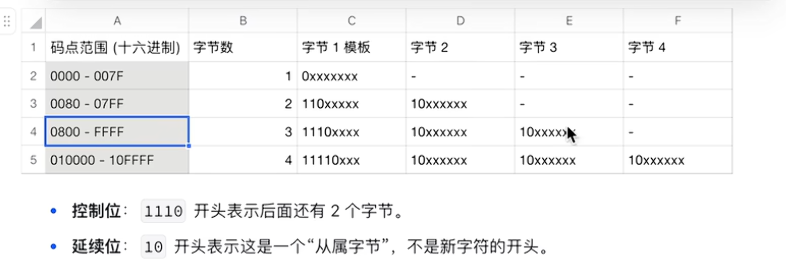

In [1]:
import torch
import torch.nn as nn

In [3]:
class demo_module(nn.Module):
    def __init__(self):
        super(demo_module, self).__init__()
        # 1. Parameter: optimizer will optimize it
        self.weight = nn.Parameter(torch.randn(1, 2))

        # 2. Buffer: 不更新梯度，但是会随着模型保存
        self.register_buffer("mask", torch.ones(2, 2))

        # 3. 浦东属性：临时Tensor 模型保存时丢失
        self.temp_data = torch.zeros(2, 2)

model = demo_module()
model.to("cuda")

print("---权重管理检查---")
print(f"1. parameter() 中包含的对象 {[n for n, p in model.named_parameters()]}")
print(f"2. buffers() 中包含的对象 {[n for n, b in model.named_buffers()]}")
print(f"3. parameter() 中包含的对象 {model.state_dict().keys()}")



---权重管理检查---
1. parameter() 中包含的对象 ['weight']
2. buffers() 中包含的对象 ['mask']
3. parameter() 中包含的对象 odict_keys(['weight', 'mask'])


In [5]:
print(model.temp_data.device)
print(model.weight.device)
print(model.mask.device)

cpu
cuda:0
cuda:0


In [12]:
w = nn.Parameter(torch.empty(1, 1000))
# print(w)
print("初始化统计")
print(f"max {w.max().item()}")
print(f"min {w.min().item()}")
print(f"mean {w.mean().item()}")
print(f"std {w.std().item()}")

nn.init.trunc_normal_(w, mean=0, std=1)

# print(w)
print("初始化后统计")
print(f"max {w.max().item()}")
print(f"min {w.min().item()}")
print(f"mean {w.mean().item()}")
print(f"std {w.std().item()}")

del w

初始化统计
max 1.9935556650161743
min 0.0
mean 0.7241711020469666
std 0.5052474737167358
初始化后统计
max 1.9889028072357178
min -1.936927318572998
mean 0.072109654545784
std 0.8707119226455688


In [33]:
# 反差变化带来的影响
d_in, d_out = 110, 110
x = torch.randn(1, d_in) # 初始输入方差 1.0

for i in range(50):
    # 如果 sigma 太大，(如 0.1)
    w_bad = torch.randn(d_out, d_in) * 0.1
    x = x @ w_bad.T
    if i % 10 == 0:
        print(f"第 {i} 层输出方差: {x.var().item():.4f}")

del x, w_bad

第 0 层输出方差: 1.0201
第 10 层输出方差: 10.7455
第 20 层输出方差: 26.6079
第 30 层输出方差: 73.9118
第 40 层输出方差: 182.4574
